# Coupled cluster theory

Companion notebook to Chapter 10 of *Quantum mechanics for many-particle
systems*.  Every number quoted in the chapter is produced here; the code is
the same as in `BookManybody/BookMaterial/Programs/coupledcluster.py`.

The ansatz is a single change from configuration interaction:

$$|\Psi\rangle = e^{\hat T}|\Phi_0\rangle,
\qquad \hat T = \hat T_1 + \hat T_2 + \cdots$$

Requiring $\overline H = e^{-\hat T}\hat H e^{\hat T}$ to have the reference
as an eigenstate gives

$$\Delta E = \langle\Phi_0|\overline H_N|\Phi_0\rangle,\qquad
  0 = \langle\Phi_i^a|\overline H_N|\Phi_0\rangle,\qquad
  0 = \langle\Phi_{ij}^{ab}|\overline H_N|\Phi_0\rangle.$$

Contents:

1. Validating the solver
2. The pairing model
3. What coupled cluster contains, order by order
4. When singles matter
5. Size extensivity
6. Everything against everything

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join("..", "BookManybody", "BookMaterial", "Programs"))
import coupledcluster as cc

np.set_printoptions(precision=6, suppress=True, linewidth=120)

## 1. Validating the solver

Four checks: the models must reproduce the exact energies of Chapters 4 and
7; the singles must vanish for the pairing model; the first iteration must be
MP2; and the Hartree-Fock rotation must leave the exact energy alone while
making $f_{ia}$ vanish.

In [2]:
cc.demo_validation()

1. Validating the solver
Everything below rests on the equations being right, so we check
them first, in four ways.

(i) The models must reproduce the exact energies of the earlier
chapters.  The pairing model against Table 4.2:
      g      E_ref       FCI here      chapter 4
  -1.00    3.00000     2.77987014     2.77987014
  -0.50    2.50000     2.43688426     2.43688426


   0.00    2.00000     2.00000000     2.00000000
   0.50    1.50000     1.41677428     1.41677428
   1.00    1.00000     0.63554847     0.63554847

(ii) For the pairing model the interaction cannot connect the
reference to a 1p-1h state, so the singles must vanish and CCSD
must equal CCD exactly:
      g            E_CCD           E_CCSD    max |t1|


   0.50    -0.0833623353    -0.0833623353    0.00e+00
   1.00    -0.3695572464    -0.3695572464    0.00e+00
   2.00    -1.6095943999    -1.6095943999    0.00e+00

(iii) The initial amplitudes are the MP2 ones, so the energy
before any iteration must be the second-order perturbation
energy.  For the pairing model this has a closed form,
   E_MP2 = -(g^2/4) [ 1/(2+g) + 2/(4+g) + 1/(6+g) ],
in which the g in each denominator is the Hartree-Fock shift of
the occupied levels -- the Moller-Plesset partition, not the bare
one-body partition used in chapter 9.
      g     MP2 computed      closed form
   0.50    -0.0623931624    -0.0623931624
   1.00    -0.2190476190    -0.2190476190
   2.00    -0.7083333333    -0.7083333333

(iv) The Hartree-Fock rotation must leave the exact energy alone
and must make the occupied-virtual block of the Fock matrix
vanish.  For the pairing plus particle-hole model of chapter 7:
    g      f      E_ref        E_HF   max |f_ia|   FCI shift


 0.50   0.25    1.00000     0.92862      4.4e-14     4.4e-16


 1.00   0.50    0.00000    -0.26976      7.7e-14     2.2e-16

The Hartree-Fock energies agree with those of chapter 7, and the
exact energy is invariant under the rotation, as it must be.


## 2. The pairing model

Four doubly degenerate levels, four particles.  The reference energy is the
Hartree-Fock energy $2-g$ of Chapter 6, so everything below is correlation
energy.

In [3]:
cc.demo_pairing()

2. The pairing model
Four doubly degenerate levels, four particles, xi = 1.  The
Hartree-Fock energy is the reference energy 2 - g, as chapter 6
found, so everything below is correlation energy.

     g     E_ref          MP2          CCD          FCI   CCD error   iter
  0.25   1.75000   1.73320261   1.73045621   1.73045985   -3.63e-06     13
  0.50   1.50000   1.43760684   1.41663766   1.41677428   -1.37e-04     18


  1.00   1.00000   0.78095238   0.63044275   0.63554847   -5.11e-03     26
  1.50   0.50000   0.05974026  -0.38416526  -0.34819051   -3.60e-02     30
  2.00   0.00000  -0.70833333  -1.60959440  -1.48965216   -1.20e-01     31

At weak coupling CCD is very nearly exact -- four parts in a
million at g = 0.25.  It over-correlates, and the error grows
with the coupling, reaching 0.12 at g = 2.  What CCD misses here
is the connected quadruple excitations: the exponential supplies
the 4p-4h amplitude as (1/2) T_2^2, which is the disconnected
part only, and for four particles in four levels the connected
part is not negligible once the interaction is strong.


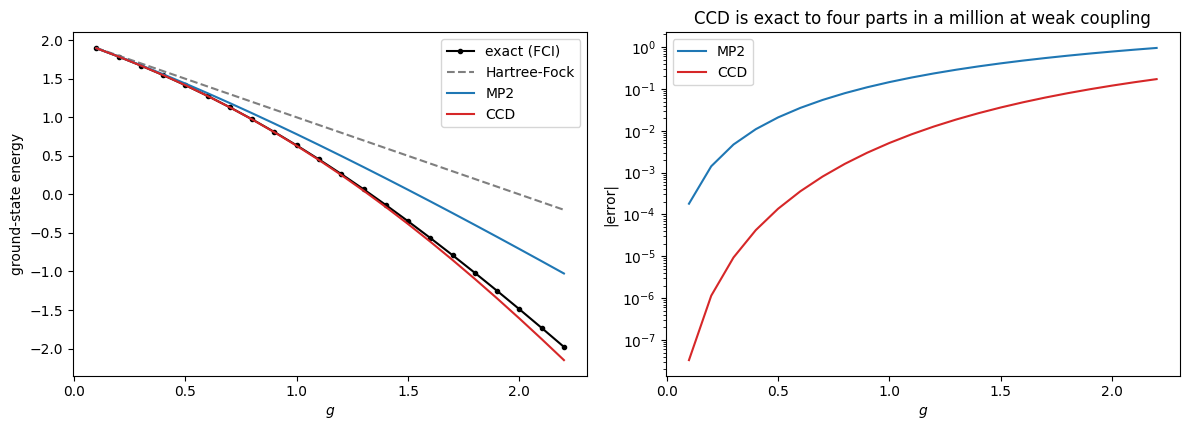

In [4]:
gs = np.linspace(0.1, 2.2, 22)
ref, mp2, ccd_e, exact = [], [], [], []
for g in gs:
    h, v, N = cc.pairing_model(g=g)
    fk = cc.fock_matrix(h, v, N)
    e0 = cc.reference_energy(h, v, N)
    ref.append(e0)
    mp2.append(e0 + cc.mp2_energy(fk, v, N))
    ccd_e.append(e0 + cc.ccd(fk, v, N)["energy"])
    exact.append(cc.fci_energy(h, v, N)[0])

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ax[0].plot(gs, exact, "k-o", ms=3, label="exact (FCI)")
ax[0].plot(gs, ref, "C7--", label="Hartree-Fock")
ax[0].plot(gs, mp2, "C0-", label="MP2")
ax[0].plot(gs, ccd_e, "C3-", label="CCD")
ax[0].set_xlabel("$g$"); ax[0].set_ylabel("ground-state energy")
ax[0].legend()
ax[1].semilogy(gs, np.abs(np.array(mp2) - np.array(exact)), "C0-", label="MP2")
ax[1].semilogy(gs, np.abs(np.array(ccd_e) - np.array(exact)), "C3-",
               label="CCD")
ax[1].set_xlabel("$g$"); ax[1].set_ylabel("|error|")
ax[1].set_title("CCD is exact to four parts in a million at weak coupling")
ax[1].legend()
fig.tight_layout(); plt.show()

## 3. What coupled cluster contains, order by order

The CCD equation is exactly quadratic in the amplitudes, so it splits as
$R(t) = C + L[t] + Q[t,t]$ and can be expanded in powers of the interaction.
The result is Møller-Plesset perturbation theory — verified here against the
independent implementation of Chapter 9.

In [5]:
cc.demo_orders()

3. What coupled cluster contains, order by order
The CCD equation is exactly quadratic in the amplitudes, so it
can be split as R(t) = C + L[t] + Q[t,t] and expanded in powers
of the interaction.  The result is perturbation theory: the first
amplitude is the MP2 one, the second generates the third-order
energy, and so on -- but the iteration never stops, so CCD
contains contributions at every order.

Against Moller-Plesset perturbation theory computed independently
in the determinant basis of chapter 9:
     g   order         from CCD        from MBPT


  0.50       2    -0.0623931624    -0.0623931624
             3    -0.0165183724    -0.0165183724
             4    -0.0038210766    -0.0038210766
  1.00       2    -0.2190476190    -0.2190476190
             3    -0.1004988662    -0.1004988662
             4    -0.0403096858    -0.0403096858

They agree to every digit through fourth order.  That CCD should
reproduce MP2 and MP3 is general; that it also gets MP4 right is
special to this model, where the interaction produces neither
singles nor triples and the quadruples enter only through the
disconnected T_2^2 that the exponential already supplies.

Summing the expansion:
   g = 0.5:  E_ref = 1.50000
        order          term     partial sum
            2    -6.239e-02    1.4376068376
            3    -1.652e-02    1.4210884652
            4    -3.821e-03    1.4172673886
            5    -6.576e-04    1.4166097534
            6    -2.979e-05    1.4165799647
            7     3.493e-05    1.4166148993
      sum of 16 orders = 1.41663

   g = 1.0:  E_ref = 1.00000
        order          term     partial sum
            2    -2.190e-01    0.7809523810
            3    -1.005e-01    0.6804535147
            4    -4.031e-02    0.6401438290
            5    -1.227e-02    0.6278741923
            6    -1.305e-03    0.6265690156
            7     1.620e-03    0.6281892811
      sum of 16 orders = 0.6304406038
      CCD              = 0.6304427536
      FCI              = 0.6355484736

   g = 1.5:  E_ref = 0.50000
        order          term     partial sum
            2    -4.403e-01    0.0597402597
            3    -2.682e-01   -0.2084938438
            4    -1.429e-01   -0.3514086780
            5    -5.860e-02   -0.4100070447
            6    -9.796e-03   -0.4198025511
            7     1.165e-02   -0.4081570359
      sum of 16 orders = -0.3844122083
      CCD              = -0.3841652556
      FCI              = -0.3481905058

The expansion converges back onto the CCD energy, as it must.
But note what has happened: at 

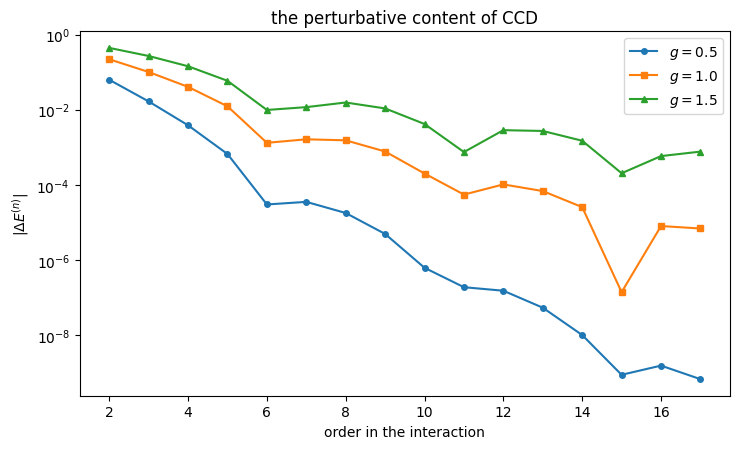

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for g, style in ((0.5, "-o"), (1.0, "-s"), (1.5, "-^")):
    h, v, N = cc.pairing_model(g=g)
    fk = cc.fock_matrix(h, v, N)
    e, _ = cc.ccd_order_by_order(fk, v, N, order=16)
    ax.semilogy(range(2, 18), np.abs(e), style, ms=4, label=f"$g = {g}$")
ax.set_xlabel("order in the interaction")
ax.set_ylabel(r"$|\Delta E^{(n)}|$")
ax.set_title("the perturbative content of CCD")
ax.legend(); fig.tight_layout(); plt.show()

The expansion converges back onto the CCD energy.  Solving the nonlinear
equation reaches the same answer in twenty-odd iterations without ever
referring to the order structure — that is what "infinite resummation" means
in practice.

## 4. When singles matter

The particle-hole term of Chapter 7 breaks pairs, so the reference couples to
$1p$-$1h$ states and the singles amplitudes are no longer zero.  We run CCSD
twice: on the bare oscillator reference and on the Hartree-Fock reference,
where Brillouin's theorem makes the singles start one order later.

In [7]:
cc.demo_ccsd()

4. When singles matter: the pairing plus particle-hole model
The particle-hole term of chapter 7 breaks pairs, so the
reference couples to 1p-1h states and the singles amplitudes do
not vanish.  This is where CCSD earns its name.  We run it twice:
on the bare oscillator reference, and on the Hartree-Fock
reference where Brillouin's theorem holds.

    g      f          CCD         CCSD      CCSD/HF          FCI      |t1|   |t1| HF
 0.50  0.025    1.3476038    1.3469075    1.3469088    1.3471327   1.1e-02   5.4e-04


 0.70  0.050    0.9707634    0.9681476    0.9681644    0.9697588   1.9e-02   1.5e-03
 1.00  0.050    0.4447429    0.4423659    0.4424119    0.4505823   1.7e-02   1.8e-03


 0.50  0.250    0.6033126    0.5467210    0.5472745    0.5511916   8.4e-02   7.3e-03
 1.00  0.500   -1.6764657   -1.7957374   -1.7805416   -1.6917367   1.0e-01   1.3e-02

Three things to read off.  The singles matter: at g = 0.5,
f = 0.25 they move the energy from 0.6033 to 0.5467 against an
exact 0.5512, turning a 9% error into a 0.8% one.  The singles
amplitudes are an order of magnitude smaller in the Hartree-Fock
basis, because Brillouin's theorem makes them start at second
order rather than first.  And the two CCSD columns are close but
not identical -- coupled cluster is not invariant under a change
of reference determinant, only exact in the untruncated limit.


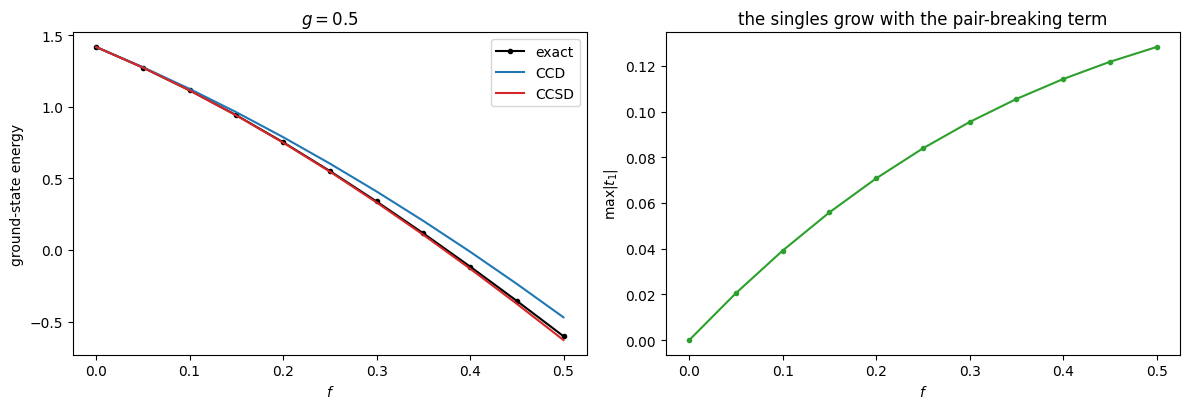

In [8]:
fs = np.linspace(0.0, 0.5, 11)
g = 0.5
d_e, s_e, ex_e, t1max = [], [], [], []
for f in fs:
    h, v, N = cc.pairing_ph_model(g=g, f=f)
    fk = cc.fock_matrix(h, v, N)
    e0 = cc.reference_energy(h, v, N)
    d_e.append(e0 + cc.ccd(fk, v, N, mixing=0.3)["energy"])
    s = cc.ccsd(fk, v, N, mixing=0.3)
    s_e.append(e0 + s["energy"]); t1max.append(np.abs(s["t1"]).max())
    ex_e.append(cc.fci_energy(h, v, N)[0])

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(fs, ex_e, "k-o", ms=3, label="exact")
ax[0].plot(fs, d_e, "C0-", label="CCD")
ax[0].plot(fs, s_e, "C3-", label="CCSD")
ax[0].set_xlabel("$f$"); ax[0].set_ylabel("ground-state energy")
ax[0].set_title(f"$g = {g}$"); ax[0].legend()
ax[1].plot(fs, t1max, "C2-o", ms=3)
ax[1].set_xlabel("$f$"); ax[1].set_ylabel(r"$\max|t_1|$")
ax[1].set_title("the singles grow with the pair-breaking term")
fig.tight_layout(); plt.show()

## 5. Size extensivity

For non-interacting subsystems the cluster operators commute, so
$e^{\hat T_A + \hat T_B} = e^{\hat T_A}e^{\hat T_B}$, the wave function
factorises and the energy is additive — at any truncation level.  This is the
property truncated configuration interaction cannot have.

In [9]:
cc.demo_extensivity()

5. Size extensivity
Chapter 5 found that truncated configuration interaction is not
size consistent, and chapter 9 that Rayleigh-Schrodinger
perturbation theory is.  Coupled cluster is size extensive by
construction: for non-interacting subsystems the cluster
operators commute and exp(T_A + T_B) = exp(T_A) exp(T_B), so the
wave function factorises and the energy is additive.

Identical, non-interacting copies of a three-level pairing
system, one pair in each:
     g       E(one copy)    E(2) - 2E(1)    E(3) - 3E(1)
  0.25   -0.012167069342        0.00e+00        0.00e+00
  0.50   -0.050059379847       -2.11e-13       -3.17e-13


  1.00   -0.205303400091        5.55e-17       -2.97e-13

Exact to machine precision at every coupling.  Compare with the
doubles configuration-interaction errors of chapter 5, which grew
from 6e-05 to 1e-02 over the same range of couplings.  This is
the single property that decides between the two methods for
extended systems, and coupled cluster gets it for free from the
exponential.


## 6. Everything against everything

In [10]:
cc.demo_comparison()

6. Everything against everything
The pairing model, treated by every method in the book.



     g        HF      MBPT2      MBPT3        CID        RPA         CCD         FCI
  0.25   1.75000    1.73177    1.73047    1.73051    1.71635   1.7304562   1.7304598
  0.50   1.50000    1.42708    1.41667    1.41760    1.37450   1.4166377   1.4167743
  1.00   1.00000    0.70833    0.62500    0.64891    0.55459   0.6304428   0.6355485
  1.50   0.50000   -0.15625   -0.43750   -0.29113   -0.40625  -0.3841653  -0.3481905
  2.00   0.00000   -1.16667   -1.83333   -1.35209   -1.47622  -1.6095944  -1.4896522

The errors:
     g       MBPT2       MBPT3         CID         RPA         CCD
  0.25    1.31e-03    8.90e-06    4.72e-05   -1.41e-02   -3.63e-06
  0.50    1.03e-02   -1.08e-04    8.22e-04   -4.23e-02   -1.37e-04
  1.00    7.28e-02   -1.05e-02    1.34e-02   -8.10e-02   -5.11e-03
  1.50    1.92e-01   -8.93e-02    5.71e-02   -5.81e-02   -3.60e-02
  2.00    3.23e-01   -3.44e-01    1.38e-01    1.34e-02   -1.20e-01

At weak and moderate coupling coupled cluster is the best of the
five by t

## 7. Unitary coupled cluster

Replacing $e^{\hat T}$ by $e^{\hat T - \hat T^\dagger}$ makes the exponential
*unitary*, so the state stays normalised and the energy

$$E(\mathbf t) = \langle\Phi_0|e^{-\hat\sigma}\hat H e^{\hat\sigma}|\Phi_0\rangle,
\qquad \hat\sigma = \hat T - \hat T^\dagger$$

is a genuine expectation value — **variational**, bounded below by $E_0$.

The price is that $[\hat T, \hat T^\dagger]\neq 0$, so the
Baker-Campbell-Hausdorff series no longer terminates and the exponential must
be built explicitly.  On a classical computer that is expensive; on a quantum
computer the exponential is *applied* rather than expanded, and the bound is
exactly what an optimiser wants.

In [11]:
cc.demo_unitary()

7. Unitary coupled cluster
Replacing exp(T) by exp(T - T^dagger) makes the transformation
unitary, so the energy becomes a true expectation value in a
normalised state and is therefore variational.  The price is that
the Baker-Campbell-Hausdorff series no longer terminates, and the
exponential must be built explicitly.

For the pairing model the generators may be taken as pair
excitations alone; adding the general doubles and singles changes
nothing, because the interaction cannot use them:
        generators   amplitudes          E(UCC)
        pairs only            4    0.6369869810


           doubles           36    0.6369869810


 singles + doubles           52    0.6369869810

The comparison that matters is with the standard theory.  UCCD is
variational and therefore always above the exact energy; CCD is
not, and crosses it:

     g     E_ref           CCD          UCCD           FCI     CCD err    UCCD err
  0.25   1.75000    1.73045621    1.73046012    1.73045985   -3.63e-06    2.76e-07


  0.50   1.50000    1.41663766    1.41679562    1.41677428   -1.37e-04    2.13e-05
  1.00   1.00000    0.63044275    0.63698698    0.63554847   -5.11e-03    1.44e-03


  1.50   0.50000   -0.38416526   -0.33675149   -0.34819051   -3.60e-02    1.14e-02
  2.00   0.00000   -1.60959440   -1.45347633   -1.48965216   -1.20e-01    3.62e-02

Every UCCD error is positive, as the variational principle
demands, and every CCD error is negative.  For this model the
unitary theory is also the more accurate of the two at every
coupling, by a factor between three and thirteen -- and it comes
with a bound that CCD cannot offer.  The two are the same
truncation of the same cluster operator, differing only in whether
the exponential is unitary; that difference is worth an order of
magnitude here.  One should not generalise too freely from a
four-particle model, but the variational property is a theorem,
not an accident.


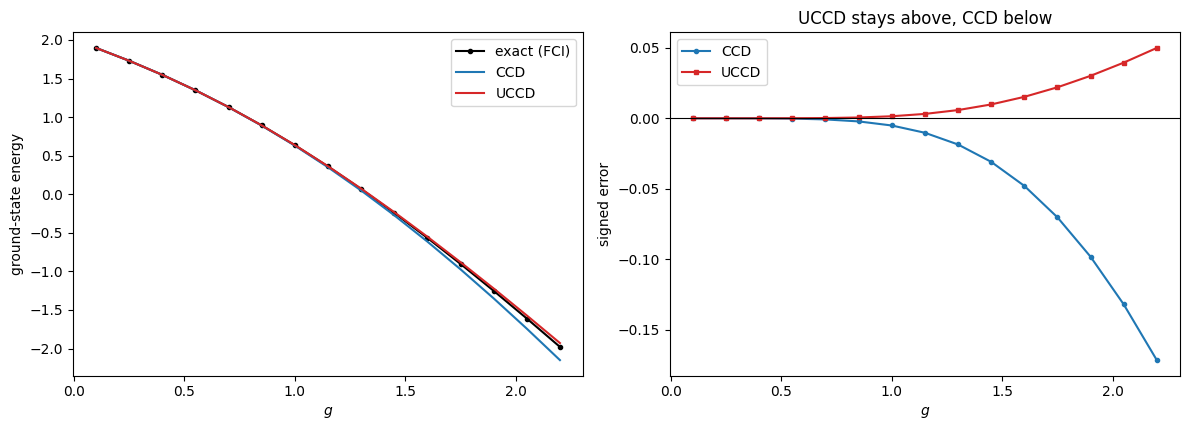

In [12]:
gs = np.linspace(0.1, 2.2, 15)
e_ccd, e_uccd, e_exact = [], [], []
for g in gs:
    h, v, N = cc.pairing_model(g=g)
    fk = cc.fock_matrix(h, v, N)
    e0 = cc.reference_energy(h, v, N)
    e_ccd.append(e0 + cc.ccd(fk, v, N)["energy"])
    u = cc.UnitaryCC(h, v, N, pair_only=True)
    e_uccd.append(u.optimise(restarts=2)["energy"])
    e_exact.append(u.exact())
e_ccd, e_uccd, e_exact = map(np.array, (e_ccd, e_uccd, e_exact))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ax[0].plot(gs, e_exact, "k-o", ms=3, label="exact (FCI)")
ax[0].plot(gs, e_ccd, "C0-", label="CCD")
ax[0].plot(gs, e_uccd, "C3-", label="UCCD")
ax[0].set_xlabel("$g$"); ax[0].set_ylabel("ground-state energy"); ax[0].legend()
ax[1].plot(gs, e_ccd - e_exact, "C0-o", ms=3, label="CCD")
ax[1].plot(gs, e_uccd - e_exact, "C3-s", ms=3, label="UCCD")
ax[1].axhline(0.0, color="k", lw=0.8)
ax[1].set_xlabel("$g$"); ax[1].set_ylabel("signed error")
ax[1].set_title("UCCD stays above, CCD below")
ax[1].legend()
fig.tight_layout(); plt.show()

The signed-error panel is the point: every UCCD error is positive, as the
variational principle demands, and every CCD error is negative.  The two are
the *same truncation of the same cluster operator* — only the unitarity of the
exponential differs.

## 8. Trotterisation

A quantum circuit cannot apply $e^{\hat\sigma}$ in one step.  It applies each
generator separately,

$$e^{\hat\sigma(\mathbf t)} \approx
  \Big[\prod_k e^{t_k(\hat A_k - \hat A_k^\dagger)/n}\Big]^n,$$

which is the Trotter splitting of Chapter 6 with the cluster generators in
place of the pieces of a Hamiltonian.

In [13]:
cc.demo_trotter()

8. Trotterisation, and a warning about it
A quantum computer cannot apply exp(sigma) directly.  It applies
the individual factors in sequence,
   [ prod_k exp( t_k (A_k - A_k^+) / n ) ]^n ,
which is the Trotter splitting of chapter 6 with the generators
in place of the pieces of a Hamiltonian.  The obvious question is
how large n must be.

Re-optimising the amplitudes for each Trotter number:
         n          E(UCCD)    error vs FCI
 exact exp     0.6369869810        1.44e-03


         1     0.6369869810        1.44e-03
         2     0.6369869810        1.44e-03
         4     0.6369869810        1.44e-03


         8     0.6369869810        1.44e-03

Every Trotter number gives the same answer to ten digits, even
n = 1.  This is not an error in the splitting: it is the
optimiser absorbing it.  The Trotterised ansatz is a different
parametrisation of a similar family of states, and the variational
search simply finds whichever amplitudes are best for the
parametrisation it is given.

To see the splitting error one has to hold the amplitudes fixed.
Taking those optimised for the exact exponential and evaluating
the Trotterised state at the same amplitudes:

    n   || psi_n - psi ||   ratio    energy error   ratio
    1           3.564e-03     nan       6.783e-05     nan
    2           1.139e-03    3.13       6.383e-06   10.63
    4           4.556e-04    2.50       9.367e-07    6.81
    8           2.112e-04    2.16       1.930e-07    4.85
   16           1.034e-04    2.04       4.569e-08    4.23
   32           5.143e-05    2.01       1.126e-08    4.06

The state converges as 1/n, which 

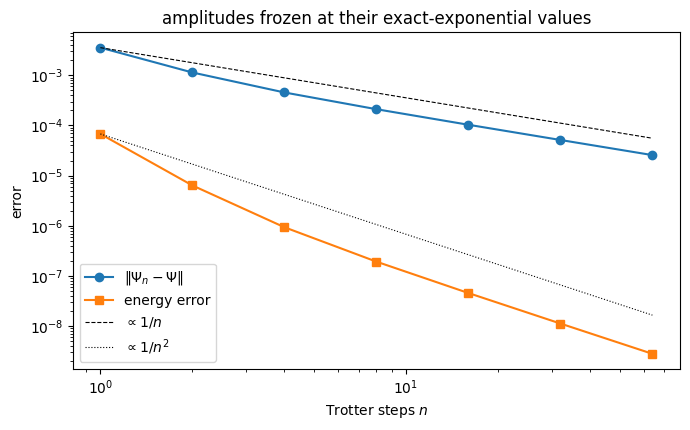

In [14]:
h, v, N = cc.pairing_model(g=1.0)
u = cc.UnitaryCC(h, v, N, pair_only=True)
ref = u.optimise(restarts=2)
t_star = ref["amplitudes"]
psi = u.state(t_star); psi /= np.linalg.norm(psi)

ns = np.array([1, 2, 4, 8, 16, 32, 64])
state_err, energy_err = [], []
for n in ns:
    p = u.state(t_star, n_trotter=int(n)); p /= np.linalg.norm(p)
    if float(psi @ p) < 0:
        p = -p
    state_err.append(np.linalg.norm(p - psi))
    energy_err.append(u.energy(t_star, n_trotter=int(n)) - ref["energy"])

fig, ax = plt.subplots(figsize=(7, 4.4))
ax.loglog(ns, state_err, "o-", label=r"$\|\Psi_n - \Psi\|$")
ax.loglog(ns, energy_err, "s-", label="energy error")
ax.loglog(ns, state_err[0] / ns, "k--", lw=0.8, label=r"$\propto 1/n$")
ax.loglog(ns, energy_err[0] / ns**2, "k:", lw=0.8, label=r"$\propto 1/n^2$")
ax.set_xlabel("Trotter steps $n$"); ax.set_ylabel("error")
ax.set_title("amplitudes frozen at their exact-exponential values")
ax.legend(); fig.tight_layout(); plt.show()

Two lessons.  **Re-optimising** the amplitudes at each Trotter number gives the
same energy to ten digits, even at $n=1$ — the optimiser absorbs the splitting
error into the amplitudes.  **Freezing** them exposes the error, and it falls
as $1/n$ in the state but $1/n^2$ in the energy, because the amplitudes sit at
a variational stationary point so the first-order response vanishes.

Both say the same thing: a variational algorithm is far more forgiving of
Trotter error than a simulation algorithm.  That is a practical argument for
VQE over straight time evolution on near-term hardware, where circuit depth is
the binding constraint.

## 9. UCCSD, where the singles matter

The pairing plus particle-hole model of Chapter 7 again.  Here the singles
generators do real work, and the contrast between the variational and the
standard theory is sharpest.

In [15]:
cc.demo_uccsd()

9. UCCSD, where the singles matter
The pairing plus particle-hole model of chapter 7 again.  Now the
singles generators do real work, and the contrast between the
variational and the standard theory is sharpest.

    g      f         UCCD        UCCSD         CCSD          FCI   UCCSD err    CCSD err


 0.50  0.025    1.3478676    1.3471722    1.3469075    1.3471327    3.96e-05   -2.25e-04


 1.00  0.050    0.4553916    0.4530194    0.4423659    0.4505823    2.44e-03   -8.22e-03


 0.50  0.250    0.6093216    0.5526429    0.5467210    0.5511916    1.45e-03   -4.47e-03


 1.00  0.500   -1.5302687   -1.6608653   -1.7957374   -1.6917367    3.09e-02   -1.04e-01

The singles are worth having: at g = 0.5, f = 0.25 they take the
energy from 0.6093 to 0.5526 against an exact 0.5512.  And every
UCCSD error is positive while every CCSD error is negative -- at
g = 1, f = 0.5 the standard theory is wrong by -0.104 and the
unitary one by +0.031, three times better and on the right side.

This is the trade that unitary coupled cluster makes.  It gives up
the terminating commutator expansion, and with it the cheap
classical algorithm, and gets back the variational bound.  On a
classical computer that is usually a bad bargain.  On a quantum
computer, where the exponential is applied rather than expanded,
the terminating expansion was never the point, and the bound is
worth having.


### This is a VQE

What we have just run *is* a variational quantum eigensolver, on a classical
simulator: a parametrised trial state $e^{\hat\sigma(\mathbf t)}|\Phi_0\rangle$
Trotterised into a gate sequence, an energy evaluated on it, and a classical
optimiser adjusting $\mathbf t$.  On hardware the energy evaluation is replaced
by repeated measurement in bases fixed by the Pauli decomposition of the
Hamiltonian.  Nothing else changes — and the `UnitaryCC` class used here is the
one Chapter 11 will build on.

## The full program

Everything above lives in
`BookManybody/BookMaterial/Programs/coupledcluster.py`, which runs as a
script and prints all six demonstrations of the chapter.

In [16]:
print(open(cc.__file__).read())

"""
Coupled-cluster theory with singles and doubles.

Companion code to chapter 10 of *Quantum mechanics for Many-particle Systems*.

The core is a general spin-orbital CCSD solver.  It takes a Fock matrix, an
antisymmetrised two-body tensor and a number of occupied orbitals, and returns
the amplitudes and the correlation energy.  Setting the singles to zero and
freezing them gives CCD.  Everything is checked against a full
configuration-interaction calculation built from the *same* one- and two-body
matrices, so that no discrepancy can be blamed on a different Hamiltonian.

    ccsd                -- the general solver, with intermediates
    ccd                 -- the same with T_1 switched off
    fci_energy          -- a small FCI in the same spin-orbital basis
    pairing_model       -- the model of chapters 4, 5, 7 and 9
    pairing_ph_model    -- the pairing plus particle-hole model of chapter 7
    ccd_order_by_order  -- the perturbative content of CCD
    UnitaryCC           -